In [2]:
import json
import numpy as np
import pandas as pd
from rich import print
from matplotlib import pyplot as plt
import cmcrameri.cm as cmc

In [3]:
# def binning(dx: float, area: str, observation: bool = False):
#     # Decide the channels to be used for inversion
#     istart_channel: int = 3
#     iend_channel: int = 25

#     # Load the configuration file
#     conf = json.load(open("../data/atem.json"))
#     n_turns = conf["n_turns"]

#     path: str = f"../data/11-024_Alberta_{area}.csv"
#     dheader: list = [f"zoff30[{i}]" for i in range(istart_channel, iend_channel)]
#     picker: list = [
#         "Line",
#         "bheight",
#         "TranPeak",
#         "x_wgs84",
#         "y_wgs84",
#         "flight",
#         "pwrline",
#         "dtm",
#     ] + dheader

#     # Load data
#     raws = pd.read_csv(path)[picker]

#     # Unit conversion and normalization
#     normalizer = (-1e-9) / (raws["TranPeak"].values * n_turns).reshape(-1, 1)
#     raws[[f"zoff30[{i}]" for i in range(istart_channel, iend_channel)]] = (
#         raws[[f"zoff30[{i}]" for i in range(istart_channel, iend_channel)]] * normalizer
#     )

#     # Extract Line number
#     line_no = list(raws["Line"].unique())
#     istart: int = 0
#     iend: int = None
#     # iend:int = 1
#     # index = raws["Line"] == line_no[istart]

#     # Reomove none data.
#     negative_mask = raws["bheight"] < 0
#     raws = raws.copy()[~negative_mask]
#     raws.dropna(
#         subset=["x_wgs84", "y_wgs84"], inplace=True
#     )  # Remove rows with NaN values in y_wgs84

#     # Data binning
#     values = []
#     values_std = []
#     size = []
#     soundings = []
#     d = 0

#     # print("==============\nData Binning Start\n==============\n")
#     for i_line, line in enumerate(line_no[istart:iend]):
#         df_line = raws[raws["Line"] == line]

#         # Calculate distance along the "Line"
#         xy = df_line[["x_wgs84", "y_wgs84"]].to_numpy()
#         distance = np.sqrt(((xy - xy[0, :]) ** 2).sum(axis=1))
#         # print(f"Number of NaN values in distance: {np.isnan(distance).sum()}")
#         max_distance = distance.max()
#         d += np.diff(distance).mean()

#         # Determine the no. of soundings per bin.
#         if max_distance % dx == 0:
#             n_sounding = int(max_distance / dx)
#         else:
#             n_sounding = int(np.floor(max_distance / dx) + 1)

#         # Create bins and assign each sounding to a bin
#         bins = np.arange(n_sounding) * dx

#         df_line = df_line.copy()
#         df_line.insert(0, "distance", distance)
#         # Bin distances
#         # df_line["bin"] = pd.cut(df_line["distance"], bins=bins) #!Fix
#         df_line["bin"] = pd.cut(df_line["distance"], bins=bins, include_lowest=True)
#         # Compute statistics per bin
#         binned = df_line.groupby("bin", observed=observation)[
#             ["distance"] + picker[1:]
#         ].mean()
#         binned_size = df_line.groupby("bin", observed=observation).size()
#         binned.insert(0, "Line", line)
#         binned_std = df_line.groupby("bin", observed=observation)[
#             ["bheight"] + dheader
#         ].std()
#         values.append(binned.values)
#         values_std.append(binned_std.values)
#         soundings.append(n_sounding)
#         size.append(binned_size.values)

#     d = d / len(line_no[istart:iend])
#     # print("==============\nData Binning End\n==============\n")
#     del raws
#     df_data_binned = pd.DataFrame(
#         data=np.vstack(values), columns=["Line", "distance"] + picker[1:]
#     )
#     df_data_std_binned = pd.DataFrame(
#         data=np.vstack(values_std), columns=["bheight"] + dheader
#     )
#     # df_data_binned.dropna(inplace=True)
#     df_data_std_binned = df_data_std_binned.loc[df_data_binned.index]
#     # df_data_std_binned.fillna(np.inf, inplace=True)

#     return df_data_binned, df_data_std_binned, size, len(line_no), d

In [ ]:
def binning(dx: float, area: str, observation: bool = False):
    # Decide the channels to be used for inversion
    istart_channel: int = 3
    iend_channel: int = 25

    # Load the configuration file
    conf = json.load(open("../data/atem.json"))
    n_turns = conf["n_turns"]

    path: str = f"../data/11-024_Alberta_{area}.csv"
    dheader: list = [f"zoff30[{i}]" for i in range(istart_channel, iend_channel)]
    picker: list = [
        "Line",
        "bheight",
        "TranPeak",
        "x_wgs84",
        "y_wgs84",
        "flight",
        "pwrline",
        "dtm",
    ] + dheader

    # Load data
    raws = pd.read_csv(path)[picker]

    # Unit conversion and normalization
    normalizer = (-1e-9) / (raws["TranPeak"].values * n_turns).reshape(-1, 1)
    raws[[f"zoff30[{i}]" for i in range(istart_channel, iend_channel)]] = (
        raws[[f"zoff30[{i}]" for i in range(istart_channel, iend_channel)]] * normalizer
    )

    # Extract Line number
    line_no = list(raws["Line"].unique())
    istart: int = 0
    iend: int = None

    # Remove none data
    negative_mask = raws["bheight"] < 0
    raws = raws.copy()[~negative_mask]
    raws.dropna(subset=["x_wgs84", "y_wgs84"], inplace=True)

    # Data binning 세팅
    values = []
    values_std = []
    size = []
    soundings = []
    d = 0

    # Filtering parameters
    sigma = dx / 2.0
    window_radius = dx * 1.5  # Distance 1.1%

    for i_line, line in enumerate(line_no[istart:iend]):
        df_line = raws[raws["Line"] == line].copy()
        if len(df_line) == 0:
            continue

        # Calculate distance along the "Line"
        xy = df_line[["x_wgs84", "y_wgs84"]].to_numpy()
        distance = np.sqrt(((xy - xy[0, :]) ** 2).sum(axis=1))
        df_line.insert(0, "distance", distance)

        max_distance = distance.max()
        d += np.diff(distance).mean()

        # Binning distances
        # Determine the no. of soundings per bin.
        if max_distance % dx == 0:
            n_sounding = int(max_distance / dx)
        else:
            n_sounding = int(np.floor(max_distance / dx) + 1)

        # Create bins and assign each sounding to a bin
        bins = np.arange(n_sounding) * dx
        n_sounding = len(bins)
        soundings.append(n_sounding)

        line_values = []
        line_std = []
        line_size = []

        # Select the target distance for each bin
        for tar_bin in bins:
            # Filter raw data within the window radius
            mask = (df_line["distance"] >= tar_bin - window_radius) & (
                df_line["distance"] <= tar_bin + window_radius
            )
            sub_df = df_line[mask]

            # If no data is found within the window radius, select the closest data point
            if len(sub_df) == 0:
                closest_idx = (df_line["distance"] - tar_bin).abs().idxmin()
                sub_df = df_line.loc[[closest_idx]]

            # Gaussian weighting (not simple average)
            dist_diff = sub_df["distance"].to_numpy() - tar_bin
            weights = np.exp(-(dist_diff**2) / (2 * sigma**2))
            weights /= weights.sum()

            # Extract numeric columns for weighted sum.
            numeric_cols = ["distance"] + picker[1:]
            features = sub_df[numeric_cols].to_numpy().astype(float)

            # Calculate weighted sum
            weighted_mean = (features * weights.reshape(-1, 1)).sum(axis=0)

            # Calculate weighted standard deviation
            std_cols = ["bheight"] + dheader
            std_features = sub_df[std_cols].to_numpy().astype(float)

            # if len(sub_df) > 1:
            #     # weighted_mean에서 bheight 시작 인덱스는 1
            #     mean_sub = weighted_mean[1 : 1 + std_features.shape[1]]
            #     weighted_var = (
            #         (std_features - mean_sub) ** 2 * weights.reshape(-1, 1)
            #     ).sum(axis=0)
            #     weighted_std = np.sqrt(weighted_var)
            # else:
            #     weighted_std = np.zeros(std_features.shape[1])
            
            # One data point case handling for weighted standard deviation
            if len(sub_df) > 1:
                mean_std_features = (std_features * weights.reshape(-1, 1)).sum(axis=0)
                weighted_var = (
                    (std_features - mean_std_features) ** 2 * weights.reshape(-1, 1)
                ).sum(axis=0)
                weighted_std = np.sqrt(weighted_var)
            else:
                weighted_std = np.zeros(std_features.shape[1])

            # 결과물 병합 (Line은 문자열로 유지)
            binned_row = np.zeros(len(numeric_cols) + 1, dtype=object)
            binned_row[0] = line
            binned_row[1:] = weighted_mean

            line_values.append(binned_row)
            line_std.append(weighted_std)
            line_size.append(len(sub_df))

        values.append(np.array(line_values, dtype=object))
        values_std.append(np.array(line_std))
        size.append(np.array(line_size))

    d = d / len(line_no[istart:iend])
    del raws

    # DataFrame Gen
    df_data_binned = pd.DataFrame(
        data=np.vstack(values), columns=["Line", "distance"] + picker[1:]
    )
    df_data_std_binned = pd.DataFrame(
        data=np.vstack(values_std), columns=["bheight"] + dheader
    )

    for col in df_data_binned.columns:
        if col != "Line":
            df_data_binned[col] = pd.to_numeric(df_data_binned[col])

    return df_data_binned, df_data_std_binned, size, len(line_no), d

In [5]:
areas = ["NW", "NE", "tielines", "SW", "SE"]

# dx = [150.0, 150.0, 150.0, 150.0, 200.0]
dx = [50.0, 50.0, 50.0, 50.0, 200.0]

In [6]:
results = {}
for i, area in enumerate(areas):
    df_binned, df_std_binned, df_size, df_n_lines, d = binning(dx[i], area)
    # df_binned, df_std_binned, df_size, df_n_lines, d = binning_new(dx[i], area)
    results[area] = {
        "df_data_binned": df_binned,
        "df_data_std_binned": df_std_binned,
        "size": df_size,
        "n_lines": df_n_lines,
        "d": d,
    }

In [7]:
print("Line Information:")
for area in areas:
    line = results[area]["df_data_binned"]["Line"].unique()
    print(f"{area}: from {line[0]} to {line[-1]} with {results[area]['n_lines']} lines")

Line Information:

NW: from L10791 to L11982 with 118 lines

NE: from L10040 to L10795 with 136 lines

tielines: from T19010 to T29252 with 57 lines

SW: from L20610 to L21555 with 115 lines

SE: from L20010 to L20600 with 87 lines

In [8]:
print("EM data sampling interval average distance:")
for area in areas:
    print(f"{area}: {results[area]['d']}")

EM data sampling interval average distance:

NW: 2.83700630548845

NE: 2.7431033002747065

tielines: 2.861587410321604

SW: 3.1655424995848525

SE: 2.978368196846555

Text(0.5, 0.98, 'Number of Soundings per Bin for Each Line')

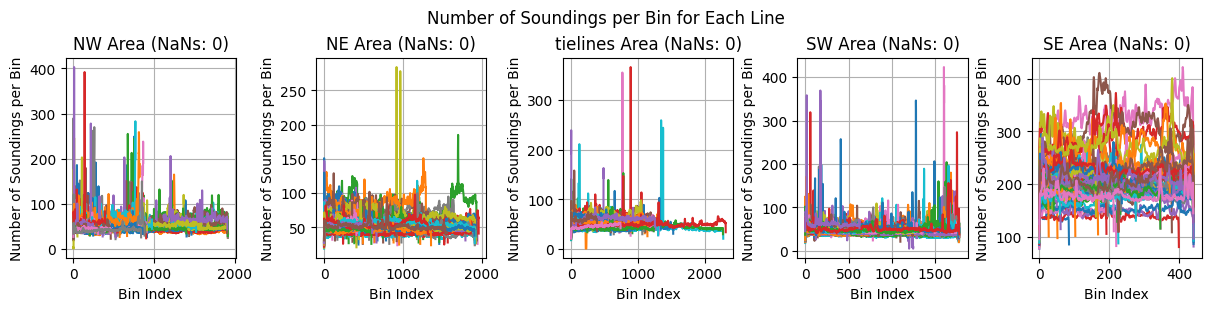

In [9]:
fig, axes = plt.subplot_mosaic([areas], figsize=(12, 3), constrained_layout=True)
for i, area in enumerate(areas):
    nlines = results[area]["n_lines"]
    nan_counts = np.isnan(
        results[area]["df_data_binned"]["x_wgs84"].values.astype(float)
    ).sum()
    for i in range(nlines):
        bin_counts = results[area]["size"][i]
        axes[area].plot(bin_counts, label=f"{area} Line {i + 1}")
    axes[area].set_ylabel("Number of Soundings per Bin")
    axes[area].set_xlabel("Bin Index")
    axes[area].grid()
    axes[area].set_title(f"{area} Area (NaNs: {nan_counts})")
plt.suptitle("Number of Soundings per Bin for Each Line")

In [10]:
def min_max_scaler(x):
    x = x.astype(float)
    log_x = np.log10(np.abs(x) + 1e-3)
    if log_x.max() - log_x.min() < 1e-3:
        scaled_x = np.zeros_like(log_x)
    else:
        scaled_x = (log_x - log_x.min()) / (log_x.max() - log_x.min())
    return scaled_x

Text(0.5, 0.98, 'Normalized Height Distribution')

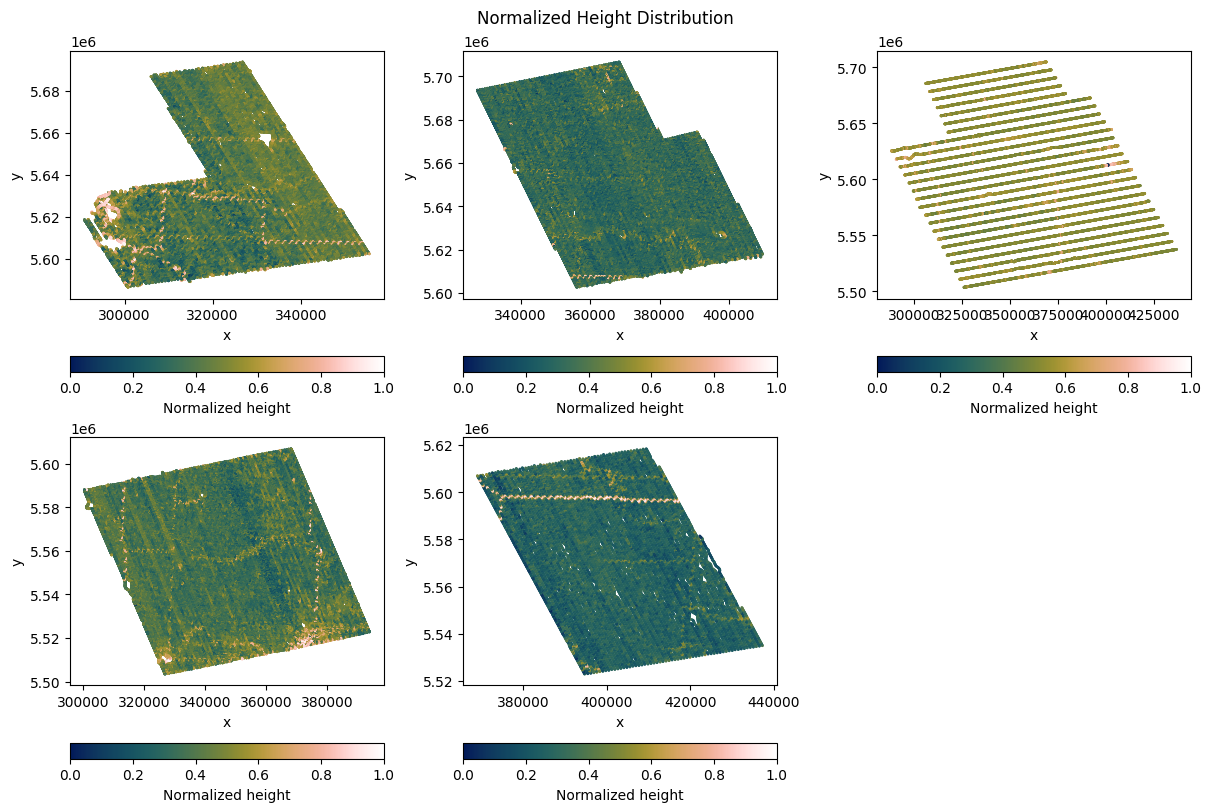

In [11]:
fig, axes = plt.subplot_mosaic(
    [areas[:3], areas[3:] + ["empty"]], figsize=(12, 8), constrained_layout=True
)
for i, area in enumerate(areas):
    nlines = results[area]["n_lines"]
    x = results[area]["df_data_binned"]["x_wgs84"]
    y = results[area]["df_data_binned"]["y_wgs84"]
    c = results[area]["df_data_binned"]["bheight"]
    scaled_c = min_max_scaler(c)
    a = axes[area].scatter(x, y, c=scaled_c, cmap=cmc.batlowW, s=1)
    axes[area].set_ylabel("y")
    axes[area].set_xlabel("x")
    plt.colorbar(a, ax=axes[area], label="Normalized height", orientation="horizontal")
axes["empty"].axis("off")
plt.suptitle("Normalized Height Distribution")

Text(0.5, 0.98, 'Normalized Power Line Distribution')

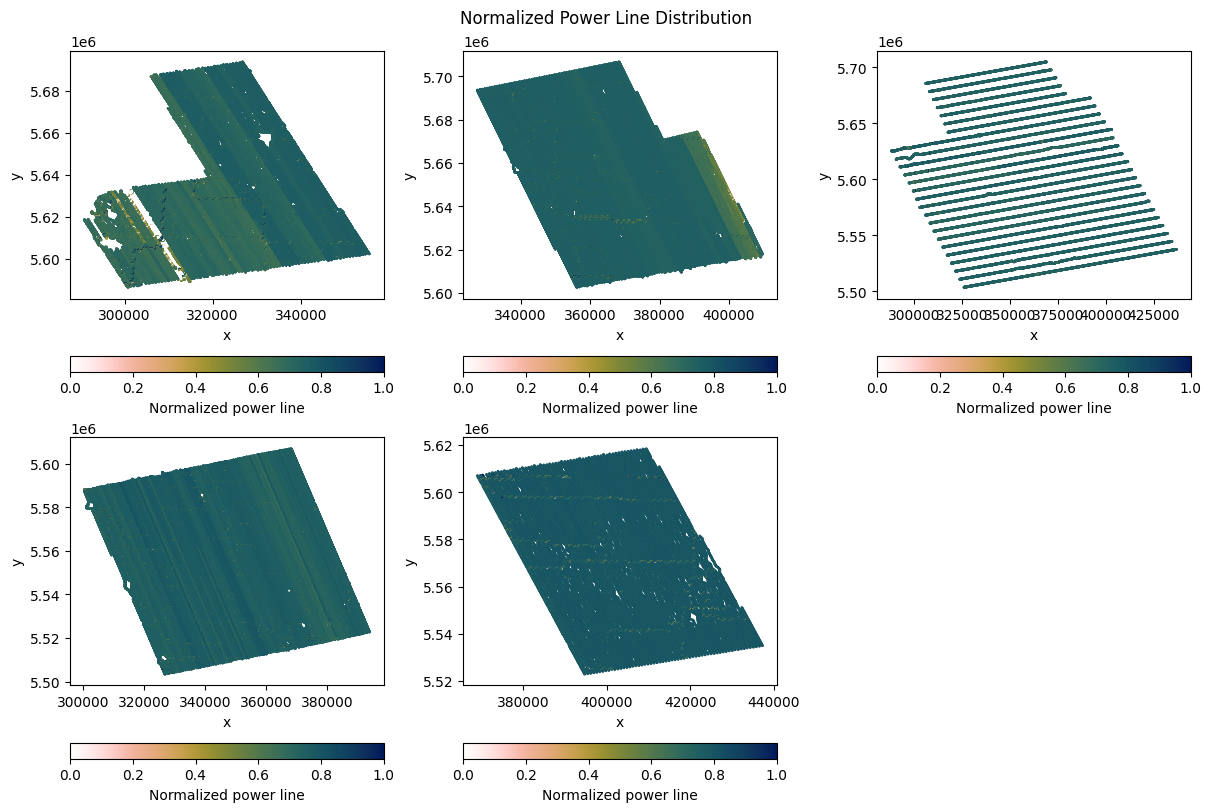

In [12]:
fig, axes = plt.subplot_mosaic(
    [areas[:3], areas[3:] + ["empty"]], figsize=(12, 8), constrained_layout=True
)
for i, area in enumerate(areas):
    nlines = results[area]["n_lines"]
    x = results[area]["df_data_binned"]["x_wgs84"]
    y = results[area]["df_data_binned"]["y_wgs84"]
    c = results[area]["df_data_binned"]["pwrline"]
    scaled_c = min_max_scaler(c)
    a = axes[area].scatter(x, y, c=scaled_c, cmap=cmc.batlowW_r, s=1)
    axes[area].set_ylabel("y")
    axes[area].set_xlabel("x")
    plt.colorbar(
        a, ax=axes[area], label="Normalized power line", orientation="horizontal"
    )
axes["empty"].axis("off")
plt.suptitle("Normalized Power Line Distribution")

Text(0.5, 0.98, 'Normalized DTM Distribution')

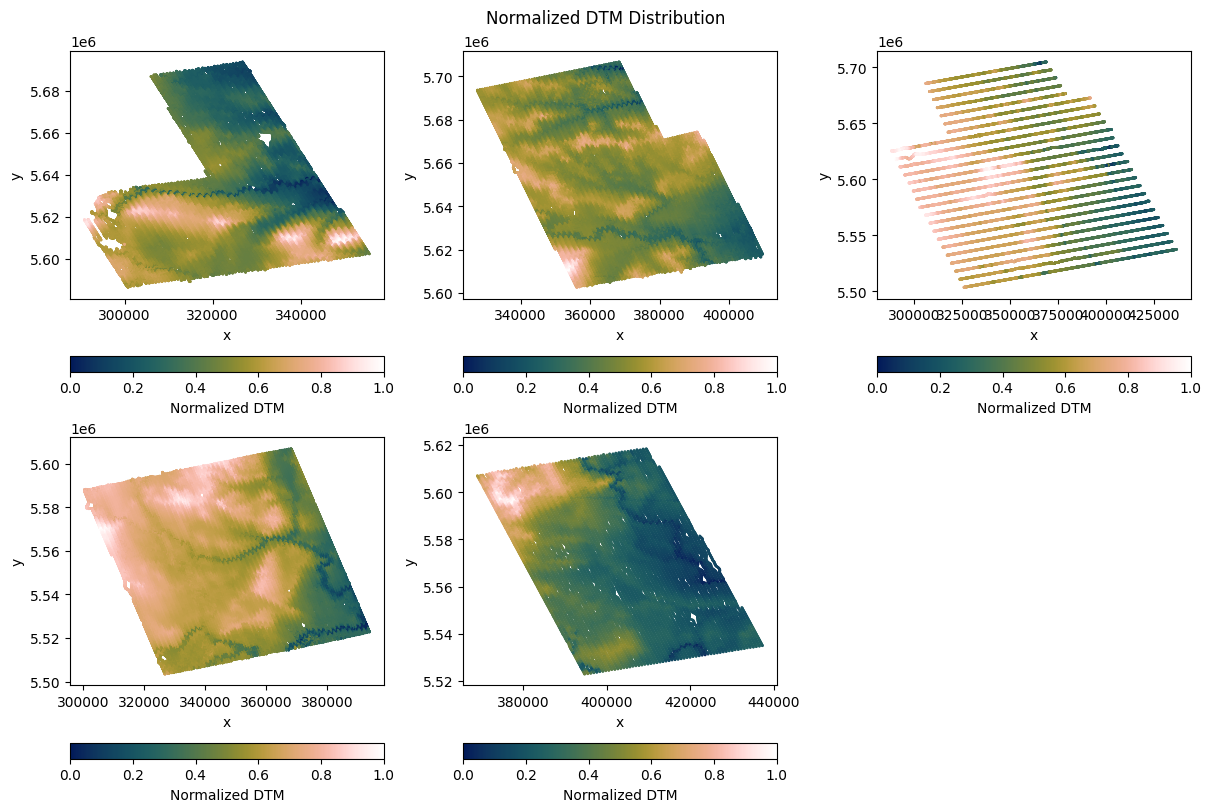

In [16]:
fig, axes = plt.subplot_mosaic(
    [areas[:3], areas[3:] + ["empty"]], figsize=(12, 8), constrained_layout=True
)
for i, area in enumerate(areas):
    nlines = results[area]["n_lines"]
    x = results[area]["df_data_binned"]["x_wgs84"]
    y = results[area]["df_data_binned"]["y_wgs84"]
    c = results[area]["df_data_binned"]["dtm"]
    scaled_c = min_max_scaler(c)
    a = axes[area].scatter(x, y, c=scaled_c, cmap=cmc.batlowW, s=1)
    axes[area].set_ylabel("y")
    axes[area].set_xlabel("x")
    plt.colorbar(
        a, ax=axes[area], label="Normalized DTM", orientation="horizontal"
    )
axes["empty"].axis("off")
plt.suptitle("Normalized DTM Distribution")